# GA Optimasi Posisi Object 2D COC

objek: Town hall, defense, storage, army

Aturan:
1. tidak boleh ada yang tumpang tindih

Setiap objek mempunyai posisi:
```
A = (x1, y1)
B = (x2, y2)
C = (x3, y3)
D = (x4, y4)
E = (x5, y5)
```

Individual
[
    (x, y, size),
    (x, y, size),
    ...
]

(x,y) menjadi koordinat pojok kiri bawah objek

### Contoh asli bangunan TH13

|	id	|	name	|	count	|	level	|	size	|	category	|	village	|
|	:------	|	:------	|	:------	|	:------	|	:------	|	:------	|	:------	|
|	1000001	|	Town Hall	|	1	|	13	|	[4, 4]	|	Town Hall	|	home	|
|	1000014	|	Clan Castle	|	1	|	9	|	[3, 3]	|	Army	|	home	|
|	1000031	|	Eagle Artillery	|	1	|	4	|	[4, 4]	|	Defense	|	home	|
|	1000067	|	Scattershot	|	2	|	2	|	[3, 3]	|	Defense	|	home	|
|	1000027	|	Inferno Tower	|	3	|	6	|	[2, 2]	|	Defense	|	home	|
|	1000021	|	X-Bow	|	4	|	5	|	[3, 3]	|	Defense	|	home	|
|	1000012	|	Air Defense	|	4	|	9	|	[3, 3]	|	Defense	|	home	|
|	1000028	|	Air Sweeper	|	2	|	7	|	[2, 2]	|	Defense	|	home	|
|	1000009	|	Archer Tower	|	8	|	15	|	[3, 3]	|	Defense	|	home	|
|	1000000	|	Army Camp	|	4	|	11	|	[4, 4]	|	Army	|	home	|
|	1000006	|	Barracks	|	1	|	15	|	[3, 3]	|	Army	|	home	|
|	1000070	|	Blacksmith	|	1	|	6	|	[3, 3]	|	Army	|	home	|
|	1000032	|	Bomb Tower	|	2	|	6	|	[3, 3]	|	Defense	|	home	|
|	1000015	|	Builder's Hut	|	5	|	1	|	[2, 2]	|	Worker	|	home	|
|	1000008	|	Cannon	|	7	|	19	|	[3, 3]	|	Defense	|	home	|
|	1000026	|	Dark Barracks	|	1	|	10	|	[3, 3]	|	Army	|	home	|
|	1000023	|	Dark Elixir Drill	|	3	|	9	|	[3, 3]	|	Resource	|	home	|
|	1000024	|	Dark Elixir Storage	|	1	|	8	|	[3, 3]	|	Resource	|	home	|
|	1000029	|	Dark Spell Factory	|	1	|	6	|	[3, 3]	|	Army	|	home	|
|	1000002	|	Elixir Collector	|	7	|	15	|	[3, 3]	|	Resource	|	home	|
|	1000003	|	Elixir Storage	|	4	|	14	|	[3, 3]	|	Resource	|	home	|
|	1000004	|	Gold Mine	|	7	|	15	|	[3, 3]	|	Resource	|	home	|
|	1000005	|	Gold Storage	|	4	|	14	|	[3, 3]	|	Resource	|	home	|
|	1000093	|	Helper Hut	|	1	|	1	|	[3, 3]	|	Helper	|	home	|
|	1000071	|	Hero Hall	|	1	|	7	|	[4, 4]	|	Army	|	home	|
|	1000019	|	Hidden Tesla	|	5	|	9	|	[2, 2]	|	Defense	|	home	|
|	1000007	|	Laboratory	|	1	|	11	|	[3, 3]	|	Army	|	home	|
|	1000013	|	Mortar	|	4	|	12	|	[3, 3]	|	Defense	|	home	|
|	1000020	|	Spell Factory	|	1	|	7	|	[3, 3]	|	Army	|	home	|
|	1000010	|	Wall	|	300	|	14	|	[1, 1]	|	Wall	|	home	|
|	1000011	|	Wizard Tower	|	5	|	10	|	[3, 3]	|	Defense	|	home	|
|	1000059	|	Workshop	|	1	|	5	|	[4, 4]	|	Army	|	home	|


## Import

In [36]:
import random
import os
import math
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from PIL import Image


## Village

In [37]:
village = {
  "townhall_level": 13,
  "building_count": 393,
  "wall_count": 300,
  "map_size": 44,
  "buildings": [
    {
      "id": 1000001,
      "name": "Town Hall",
      "level": 13,
      "size": [4, 4],
      "category": "Town Hall",
      "village": "home",
      "instance": 1
    },
    {
      "id": 1000014,
      "name": "Clan Castle",
      "level": 9,
      "size": [3, 3],
      "category": "Army",
      "village": "home",
      "instance": 1
    },
    {
      "id": 1000031,
      "name": "Eagle Artillery",
      "level": 4,
      "size": [4, 4],
      "category": "Defense",
      "village": "home",
      "instance": 1
    },
    {
      "id": 1000067,
      "name": "Scattershot",
      "level": 2,
      "size": [3, 3],
      "category": "Defense",
      "village": "home",
      "instance": 1
    },
    {
      "id": 1000067,
      "name": "Scattershot",
      "level": 2,
      "size": [3, 3],
      "category": "Defense",
      "village": "home",
      "instance": 2
    },
    {
      "id": 1000027,
      "name": "Inferno Tower",
      "level": 6,
      "size": [2, 2],
      "category": "Defense",
      "village": "home",
      "instance": 1
    },
    {
      "id": 1000027,
      "name": "Inferno Tower",
      "level": 6,
      "size": [2, 2],
      "category": "Defense",
      "village": "home",
      "instance": 2
    },
    {
      "id": 1000027,
      "name": "Inferno Tower",
      "level": 6,
      "size": [2, 2],
      "category": "Defense",
      "village": "home",
      "instance": 3
    },
    {
      "id": 1000021,
      "name": "X-Bow",
      "level": 5,
      "size": [3, 3],
      "category": "Defense",
      "village": "home",
      "instance": 1
    },
    {
      "id": 1000021,
      "name": "X-Bow",
      "level": 5,
      "size": [3, 3],
      "category": "Defense",
      "village": "home",
      "instance": 2
    },
    {
      "id": 1000021,
      "name": "X-Bow",
      "level": 5,
      "size": [3, 3],
      "category": "Defense",
      "village": "home",
      "instance": 3
    },
    {
      "id": 1000021,
      "name": "X-Bow",
      "level": 5,
      "size": [3, 3],
      "category": "Defense",
      "village": "home",
      "instance": 4
    },
    {
      "id": 1000012,
      "name": "Air Defense",
      "level": 9,
      "size": [3, 3],
      "category": "Defense",
      "village": "home",
      "instance": 1
    },
    {
      "id": 1000012,
      "name": "Air Defense",
      "level": 9,
      "size": [3, 3],
      "category": "Defense",
      "village": "home",
      "instance": 2
    },
    {
      "id": 1000012,
      "name": "Air Defense",
      "level": 9,
      "size": [3, 3],
      "category": "Defense",
      "village": "home",
      "instance": 3
    },
    {
      "id": 1000012,
      "name": "Air Defense",
      "level": 9,
      "size": [3, 3],
      "category": "Defense",
      "village": "home",
      "instance": 4
    },
    {
      "id": 1000028,
      "name": "Air Sweeper",
      "level": 7,
      "size": [2, 2],
      "category": "Defense",
      "village": "home",
      "instance": 1
    },
    {
      "id": 1000028,
      "name": "Air Sweeper",
      "level": 7,
      "size": [2, 2],
      "category": "Defense",
      "village": "home",
      "instance": 2
    },
    {
      "id": 1000009,
      "name": "Archer Tower",
      "level": 15,
      "size": [3, 3],
      "category": "Defense",
      "village": "home",
      "instance": 1
    },
    {
      "id": 1000009,
      "name": "Archer Tower",
      "level": 15,
      "size": [3, 3],
      "category": "Defense",
      "village": "home",
      "instance": 2
    },
    {
      "id": 1000009,
      "name": "Archer Tower",
      "level": 15,
      "size": [3, 3],
      "category": "Defense",
      "village": "home",
      "instance": 3
    },
    {
      "id": 1000009,
      "name": "Archer Tower",
      "level": 15,
      "size": [3, 3],
      "category": "Defense",
      "village": "home",
      "instance": 4
    },
    {
      "id": 1000009,
      "name": "Archer Tower",
      "level": 15,
      "size": [3, 3],
      "category": "Defense",
      "village": "home",
      "instance": 5
    },
    {
      "id": 1000009,
      "name": "Archer Tower",
      "level": 15,
      "size": [3, 3],
      "category": "Defense",
      "village": "home",
      "instance": 6
    },
    {
      "id": 1000009,
      "name": "Archer Tower",
      "level": 15,
      "size": [3, 3],
      "category": "Defense",
      "village": "home",
      "instance": 7
    },
    {
      "id": 1000009,
      "name": "Archer Tower",
      "level": 15,
      "size": [3, 3],
      "category": "Defense",
      "village": "home",
      "instance": 8
    },
    {
      "id": 1000000,
      "name": "Army Camp",
      "level": 11,
      "size": [4, 4],
      "category": "Army",
      "village": "home",
      "instance": 1
    },
    {
      "id": 1000000,
      "name": "Army Camp",
      "level": 11,
      "size": [4, 4],
      "category": "Army",
      "village": "home",
      "instance": 2
    },
    {
      "id": 1000000,
      "name": "Army Camp",
      "level": 11,
      "size": [4, 4],
      "category": "Army",
      "village": "home",
      "instance": 3
    },
    {
      "id": 1000000,
      "name": "Army Camp",
      "level": 11,
      "size": [4, 4],
      "category": "Army",
      "village": "home",
      "instance": 4
    },
    {
      "id": 1000006,
      "name": "Barracks",
      "level": 15,
      "size": [3, 3],
      "category": "Army",
      "village": "home",
      "instance": 1
    },
    {
      "id": 1000070,
      "name": "Blacksmith",
      "level": 6,
      "size": [3, 3],
      "category": "Army",
      "village": "home",
      "instance": 1
    },
    {
      "id": 1000032,
      "name": "Bomb Tower",
      "level": 6,
      "size": [3, 3],
      "category": "Defense",
      "village": "home",
      "instance": 1
    },
    {
      "id": 1000032,
      "name": "Bomb Tower",
      "level": 6,
      "size": [3, 3],
      "category": "Defense",
      "village": "home",
      "instance": 2
    },
    {
      "id": 1000015,
      "name": "Builder's Hut",
      "level": 1,
      "size": [2, 2],
      "category": "Worker",
      "village": "home",
      "instance": 1
    },
    {
      "id": 1000015,
      "name": "Builder's Hut",
      "level": 1,
      "size": [2, 2],
      "category": "Worker",
      "village": "home",
      "instance": 2
    },
    {
      "id": 1000015,
      "name": "Builder's Hut",
      "level": 1,
      "size": [2, 2],
      "category": "Worker",
      "village": "home",
      "instance": 3
    },
    {
      "id": 1000015,
      "name": "Builder's Hut",
      "level": 1,
      "size": [2, 2],
      "category": "Worker",
      "village": "home",
      "instance": 4
    },
    {
      "id": 1000015,
      "name": "Builder's Hut",
      "level": 1,
      "size": [2, 2],
      "category": "Worker",
      "village": "home",
      "instance": 5
    },
    {
      "id": 1000008,
      "name": "Cannon",
      "level": 19,
      "size": [3, 3],
      "category": "Defense",
      "village": "home",
      "instance": 1
    },
    {
      "id": 1000008,
      "name": "Cannon",
      "level": 19,
      "size": [3, 3],
      "category": "Defense",
      "village": "home",
      "instance": 2
    },
    {
      "id": 1000008,
      "name": "Cannon",
      "level": 19,
      "size": [3, 3],
      "category": "Defense",
      "village": "home",
      "instance": 3
    },
    {
      "id": 1000008,
      "name": "Cannon",
      "level": 19,
      "size": [3, 3],
      "category": "Defense",
      "village": "home",
      "instance": 4
    },
    {
      "id": 1000008,
      "name": "Cannon",
      "level": 19,
      "size": [3, 3],
      "category": "Defense",
      "village": "home",
      "instance": 5
    },
    {
      "id": 1000008,
      "name": "Cannon",
      "level": 19,
      "size": [3, 3],
      "category": "Defense",
      "village": "home",
      "instance": 6
    },
    {
      "id": 1000008,
      "name": "Cannon",
      "level": 19,
      "size": [3, 3],
      "category": "Defense",
      "village": "home",
      "instance": 7
    },
    {
      "id": 1000026,
      "name": "Dark Barracks",
      "level": 10,
      "size": [3, 3],
      "category": "Army",
      "village": "home",
      "instance": 1
    },
    {
      "id": 1000023,
      "name": "Dark Elixir Drill",
      "level": 9,
      "size": [3, 3],
      "category": "Resource",
      "village": "home",
      "instance": 1
    },
    {
      "id": 1000023,
      "name": "Dark Elixir Drill",
      "level": 9,
      "size": [3, 3],
      "category": "Resource",
      "village": "home",
      "instance": 2
    },
    {
      "id": 1000023,
      "name": "Dark Elixir Drill",
      "level": 9,
      "size": [3, 3],
      "category": "Resource",
      "village": "home",
      "instance": 3
    },
    {
      "id": 1000024,
      "name": "Dark Elixir Storage",
      "level": 8,
      "size": [3, 3],
      "category": "Resource",
      "village": "home",
      "instance": 1
    },
    {
      "id": 1000029,
      "name": "Dark Spell Factory",
      "level": 6,
      "size": [3, 3],
      "category": "Army",
      "village": "home",
      "instance": 1
    },
    {
      "id": 1000002,
      "name": "Elixir Collector",
      "level": 15,
      "size": [3, 3],
      "category": "Resource",
      "village": "home",
      "instance": 1
    },
    {
      "id": 1000002,
      "name": "Elixir Collector",
      "level": 15,
      "size": [3, 3],
      "category": "Resource",
      "village": "home",
      "instance": 2
    },
    {
      "id": 1000002,
      "name": "Elixir Collector",
      "level": 15,
      "size": [3, 3],
      "category": "Resource",
      "village": "home",
      "instance": 3
    },
    {
      "id": 1000002,
      "name": "Elixir Collector",
      "level": 15,
      "size": [3, 3],
      "category": "Resource",
      "village": "home",
      "instance": 4
    },
    {
      "id": 1000002,
      "name": "Elixir Collector",
      "level": 15,
      "size": [3, 3],
      "category": "Resource",
      "village": "home",
      "instance": 5
    },
    {
      "id": 1000002,
      "name": "Elixir Collector",
      "level": 15,
      "size": [3, 3],
      "category": "Resource",
      "village": "home",
      "instance": 6
    },
    {
      "id": 1000002,
      "name": "Elixir Collector",
      "level": 15,
      "size": [3, 3],
      "category": "Resource",
      "village": "home",
      "instance": 7
    },
    {
      "id": 1000003,
      "name": "Elixir Storage",
      "level": 14,
      "size": [3, 3],
      "category": "Resource",
      "village": "home",
      "instance": 1
    },
    {
      "id": 1000003,
      "name": "Elixir Storage",
      "level": 14,
      "size": [3, 3],
      "category": "Resource",
      "village": "home",
      "instance": 2
    },
    {
      "id": 1000003,
      "name": "Elixir Storage",
      "level": 14,
      "size": [3, 3],
      "category": "Resource",
      "village": "home",
      "instance": 3
    },
    {
      "id": 1000003,
      "name": "Elixir Storage",
      "level": 14,
      "size": [3, 3],
      "category": "Resource",
      "village": "home",
      "instance": 4
    },
    {
      "id": 1000004,
      "name": "Gold Mine",
      "level": 15,
      "size": [3, 3],
      "category": "Resource",
      "village": "home",
      "instance": 1
    },
    {
      "id": 1000004,
      "name": "Gold Mine",
      "level": 15,
      "size": [3, 3],
      "category": "Resource",
      "village": "home",
      "instance": 2
    },
    {
      "id": 1000004,
      "name": "Gold Mine",
      "level": 15,
      "size": [3, 3],
      "category": "Resource",
      "village": "home",
      "instance": 3
    },
    {
      "id": 1000004,
      "name": "Gold Mine",
      "level": 15,
      "size": [3, 3],
      "category": "Resource",
      "village": "home",
      "instance": 4
    },
    {
      "id": 1000004,
      "name": "Gold Mine",
      "level": 15,
      "size": [3, 3],
      "category": "Resource",
      "village": "home",
      "instance": 5
    },
    {
      "id": 1000004,
      "name": "Gold Mine",
      "level": 15,
      "size": [3, 3],
      "category": "Resource",
      "village": "home",
      "instance": 6
    },
    {
      "id": 1000004,
      "name": "Gold Mine",
      "level": 15,
      "size": [3, 3],
      "category": "Resource",
      "village": "home",
      "instance": 7
    },
    {
      "id": 1000005,
      "name": "Gold Storage",
      "level": 14,
      "size": [3, 3],
      "category": "Resource",
      "village": "home",
      "instance": 1
    },
    {
      "id": 1000005,
      "name": "Gold Storage",
      "level": 14,
      "size": [3, 3],
      "category": "Resource",
      "village": "home",
      "instance": 2
    },
    {
      "id": 1000005,
      "name": "Gold Storage",
      "level": 14,
      "size": [3, 3],
      "category": "Resource",
      "village": "home",
      "instance": 3
    },
    {
      "id": 1000005,
      "name": "Gold Storage",
      "level": 14,
      "size": [3, 3],
      "category": "Resource",
      "village": "home",
      "instance": 4
    },
    {
      "id": 1000093,
      "name": "Helper Hut",
      "level": 1,
      "size": [3, 3],
      "category": "Helper",
      "village": "home",
      "instance": 1
    },
    {
      "id": 1000071,
      "name": "Hero Hall",
      "level": 7,
      "size": [4, 4],
      "category": "Army",
      "village": "home",
      "instance": 1
    },
    {
      "id": 1000019,
      "name": "Hidden Tesla",
      "level": 9,
      "size": [2, 2],
      "category": "Defense",
      "village": "home",
      "instance": 1
    },
    {
      "id": 1000019,
      "name": "Hidden Tesla",
      "level": 9,
      "size": [2, 2],
      "category": "Defense",
      "village": "home",
      "instance": 2
    },
    {
      "id": 1000019,
      "name": "Hidden Tesla",
      "level": 9,
      "size": [2, 2],
      "category": "Defense",
      "village": "home",
      "instance": 3
    },
    {
      "id": 1000019,
      "name": "Hidden Tesla",
      "level": 9,
      "size": [2, 2],
      "category": "Defense",
      "village": "home",
      "instance": 4
    },
    {
      "id": 1000019,
      "name": "Hidden Tesla",
      "level": 9,
      "size": [2, 2],
      "category": "Defense",
      "village": "home",
      "instance": 5
    },
    {
      "id": 1000007,
      "name": "Laboratory",
      "level": 11,
      "size": [3, 3],
      "category": "Army",
      "village": "home",
      "instance": 1
    },
    {
      "id": 1000013,
      "name": "Mortar",
      "level": 12,
      "size": [3, 3],
      "category": "Defense",
      "village": "home",
      "instance": 1
    },
    {
      "id": 1000013,
      "name": "Mortar",
      "level": 12,
      "size": [3, 3],
      "category": "Defense",
      "village": "home",
      "instance": 2
    },
    {
      "id": 1000013,
      "name": "Mortar",
      "level": 12,
      "size": [3, 3],
      "category": "Defense",
      "village": "home",
      "instance": 3
    },
    {
      "id": 1000013,
      "name": "Mortar",
      "level": 12,
      "size": [3, 3],
      "category": "Defense",
      "village": "home",
      "instance": 4
    },
    {
      "id": 1000020,
      "name": "Spell Factory",
      "level": 7,
      "size": [3, 3],
      "category": "Army",
      "village": "home",
      "instance": 1
    },
    {
      "id": 1000011,
      "name": "Wizard Tower",
      "level": 10,
      "size": [3, 3],
      "category": "Defense",
      "village": "home",
      "instance": 1
    },
    {
      "id": 1000011,
      "name": "Wizard Tower",
      "level": 10,
      "size": [3, 3],
      "category": "Defense",
      "village": "home",
      "instance": 2
    },
    {
      "id": 1000011,
      "name": "Wizard Tower",
      "level": 10,
      "size": [3, 3],
      "category": "Defense",
      "village": "home",
      "instance": 3
    },
    {
      "id": 1000011,
      "name": "Wizard Tower",
      "level": 10,
      "size": [3, 3],
      "category": "Defense",
      "village": "home",
      "instance": 4
    },
    {
      "id": 1000011,
      "name": "Wizard Tower",
      "level": 10,
      "size": [3, 3],
      "category": "Defense",
      "village": "home",
      "instance": 5
    },
    {
      "id": 1000059,
      "name": "Workshop",
      "level": 5,
      "size": [4, 4],
      "category": "Army",
      "village": "home",
      "instance": 1
    }
  ]
}


## Parameter

In [38]:
# =========================================
# 1. Parameter Genetic Algorithm
# =========================================

POPULATION_SIZE = 50
GENERATIONS = 250
MUTATION_RATE = 0.1

GRID_SIZE = 44

OVERLAP_PENALTY = 100
BOUNDARY_PENALTY = 100

BUILDINGS = village["buildings"]
NUMBER_OF_OBJECTS = len(BUILDINGS)


In [39]:
total_area = sum(
    building["size"][0] * building["size"][1]
    for building in BUILDINGS
)

print("Total building area:", total_area)
print("Map area:", GRID_SIZE * GRID_SIZE)

Total building area: 818
Map area: 1936


## Function

In [40]:
# =========================================
# Fungsi Distance
# =========================================

def distance(point1, point2):

    x1, y1 = point1
    x2, y2 = point2

    return math.sqrt(
        (x2 - x1) ** 2 +
        (y2 - y1) ** 2
    )

def center_distance(position, size):

    x, y = building_center(
        position,
        size
    )

    center_x = GRID_SIZE / 2
    center_y = GRID_SIZE / 2

    return math.sqrt(
        (x - center_x) ** 2 +
        (y - center_y) ** 2
    )
    
# =========================================
# Fungsi Overlap bangunan 2D
# =========================================
def is_overlap(pos1, size1, pos2, size2):

    x1, y1 = pos1
    w1, h1 = size1

    x2, y2 = pos2
    w2, h2 = size2

    return (
        x1 < x2 + w2 and
        x1 + w1 > x2 and
        y1 < y2 + h2 and
        y1 + h1 > y2
    )


# =========================================
# 2. Fungsi Fitness yang Diperbarui
# =========================================

def fitness(individual):
    penalty = 0
    
    # 1. Cek Boundary (Batas Peta)
    for i, building in enumerate(BUILDINGS):
        x, y = individual[i]
        width, height = building["size"]

        if x < 0:
            penalty += abs(x) * BOUNDARY_PENALTY
        if y < 0:
            penalty += abs(y) * BOUNDARY_PENALTY
        if x + width > GRID_SIZE:
            penalty += (x + width - GRID_SIZE) * BOUNDARY_PENALTY
        if y + height > GRID_SIZE:
            penalty += (y + height - GRID_SIZE) * BOUNDARY_PENALTY

    # 2. Cek Overlap Antar Bangunan
    for i in range(NUMBER_OF_OBJECTS):
        for j in range(i + 1, NUMBER_OF_OBJECTS):
            pos1 = individual[i]
            size1 = BUILDINGS[i]["size"]
            
            pos2 = individual[j]
            size2 = BUILDINGS[j]["size"]

            if is_overlap(pos1, size1, pos2, size2):
                # Hitung luas area yang tumpang tindih agar penalti lebih akurat
                x_overlap = max(0, min(pos1[0] + size1[0], pos2[0] + size2[0]) - max(pos1[0], pos2[0]))
                y_overlap = max(0, min(pos1[1] + size1[1], pos2[1] + size2[1]) - max(pos1[1], pos2[1]))
                overlap_area = x_overlap * y_overlap
                
                penalty += overlap_area * OVERLAP_PENALTY

    # Semakin kecil penalti, semakin tinggi fitness (mendekati 0 adalah ideal)
    return -penalty
    


# =========================================
# 3. Membuat individual
# =========================================

def create_individual():

    individual = []

    for building in BUILDINGS:

        width, height = building["size"]

        max_x = GRID_SIZE - width
        max_y = GRID_SIZE - height

        x = random.randint(0, max_x)
        y = random.randint(0, max_y)

        individual.append((x, y))

    return individual

In [41]:
# =========================================
# 5. Membuat population
# =========================================

def create_population():
    return [
        create_individual()
        for _ in range(POPULATION_SIZE)
    ]


# =========================================
# 6. Selection
# =========================================

def selection(population):
    population_sorted = sorted(
        population,
        key=fitness,
        reverse=True
    )

    # Ambil 50% terbaik
    return population_sorted[:POPULATION_SIZE // 2]


# =========================================
# 7. Crossover
# =========================================
def crossover(parent1, parent2):

    child1 = []
    child2 = []

    for i in range(NUMBER_OF_OBJECTS):

        if random.random() < 0.5:

            child1.append(parent1[i])
            child2.append(parent2[i])

        else:

            child1.append(parent2[i])
            child2.append(parent1[i])

    return child1, child2

# =========================================
# 8. Mutation
# =========================================
def mutation(individual):

    for i in range(NUMBER_OF_OBJECTS):

        if random.random() < MUTATION_RATE:

            width, height = BUILDINGS[i]["size"]

            max_x = GRID_SIZE - width
            max_y = GRID_SIZE - height

            x = random.randint(0, max_x)
            y = random.randint(0, max_y)

            individual[i] = (x, y)

    return individual




## Run GA

Generation 01 | Fitness = -12200.00 | Position = [(28, 27), (35, 27), (23, 9), (41, 3), (20, 34), (7, 27), (11, 33), (15, 30), (2, 19), (39, 12), (24, 4), (13, 37), (9, 2), (8, 28), (30, 33), (38, 27), (40, 33), (6, 11), (0, 29), (17, 14), (31, 24), (33, 13), (12, 30), (19, 32), (16, 36), (25, 27), (14, 18), (23, 20), (40, 19), (4, 18), (10, 38), (38, 23), (33, 3), (15, 11), (23, 11), (38, 17), (1, 5), (4, 17), (26, 33), (26, 0), (40, 2), (35, 17), (5, 9), (38, 2), (2, 38), (23, 31), (21, 22), (41, 9), (10, 3), (23, 15), (26, 14), (22, 6), (24, 22), (35, 34), (28, 2), (8, 2), (8, 18), (19, 19), (0, 8), (28, 35), (17, 10), (41, 25), (10, 8), (16, 32), (26, 33), (30, 22), (5, 36), (24, 30), (7, 40), (3, 31), (21, 11), (22, 31), (2, 0), (28, 36), (15, 4), (1, 9), (40, 26), (35, 14), (4, 30), (19, 24), (15, 34), (37, 11), (21, 9), (30, 13), (31, 39), (21, 28), (22, 16), (35, 2), (6, 26), (0, 24), (0, 0), (37, 3), (38, 28)]
Generation 02 | Fitness = -12200.00 | Position = [(28, 27), (35, 27

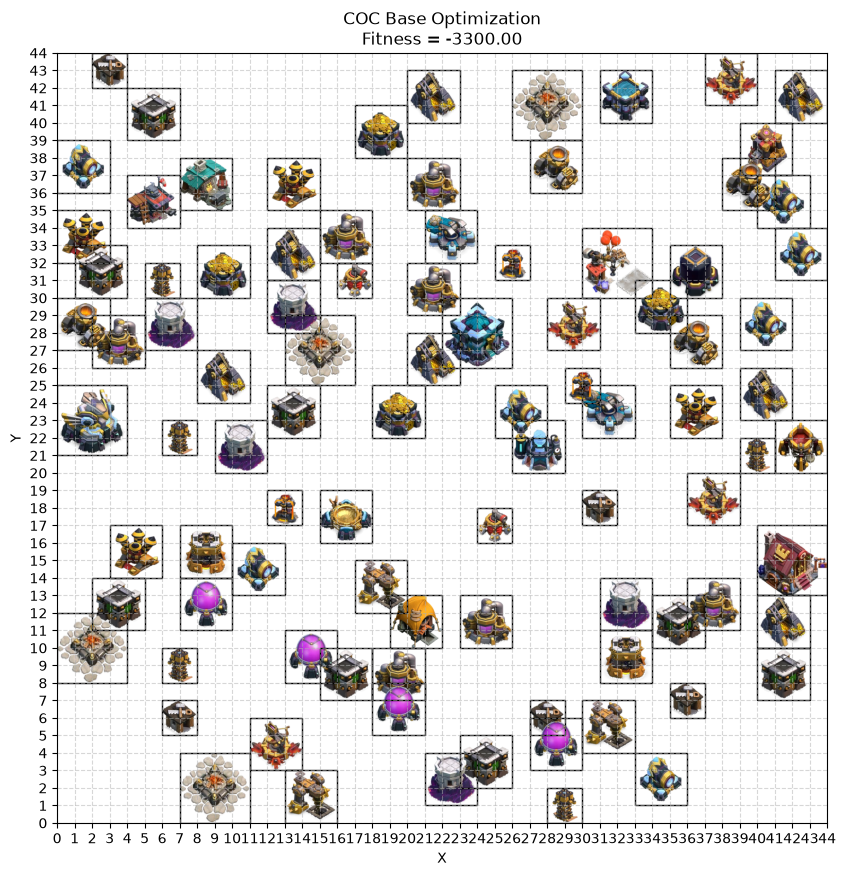

In [42]:
# =========================================
# 9. Genetic Algorithm
# =========================================

population = create_population()


for generation in range(GENERATIONS):

    # -----------------------------
    # Evaluasi
    # -----------------------------

    best = max(
        population,
        key=fitness
    )

    print(
        f"Generation {generation + 1:02d} | "
        f"Fitness = {fitness(best):.2f} | "
        f"Position = {best}"
    )


    # -----------------------------
    # Selection
    # -----------------------------

    parents = selection(population)


    # -----------------------------
    # Membuat population baru
    # -----------------------------

    new_population = parents.copy()


    while len(new_population) < POPULATION_SIZE:

        parent1, parent2 = random.sample(parents, 2)

        child1, child2 = crossover(
            parent1,
            parent2
        )

        child1 = mutation(child1)
        child2 = mutation(child2)

        new_population.append(child1)

        if len(new_population) < POPULATION_SIZE:
            new_population.append(child2)


    population = new_population


# =========================================
# 10. Hasil akhir
# =========================================

best = max(
    population,
    key=fitness
)

print("\nHasil Akhir")

print("Position :", best)
print("Fitness  :", fitness(best))



# =========================================
# 11. Visualisasi
# =========================================

fig, ax = plt.subplots(figsize=(10, 10))

for i, (x, y) in enumerate(best):
  bld = BUILDINGS[i]
  width, height = bld["size"]
  name = bld["name"]
  bld_id = bld["id"]
  level = bld["level"]

  rectangle = Rectangle(
      (x, y), width, height, fill=False, linewidth=1, edgecolor="black"
  )
  ax.add_patch(rectangle)

  folder_name_suffix = name.lower().replace(" ", "_")
  folder_path = f"../../../assets/buildings/{bld_id}_{folder_name_suffix}"

  file_prefix = name.replace(" ", "_")
  img_filename = f"{file_prefix}{level}.webp"
  img_path = os.path.join(folder_path, img_filename)

  try:
    if os.path.exists(img_path):
      img = Image.open(img_path)
      ax.imshow(img, extent=(x, x + width, y, y + height), aspect="auto")
    else:
      print(f"Gambar tidak ditemukan: {img_path}")
  except Exception as e:
    print(f"Gagal memuat gambar {name}: {e}")

#   ax.text(
#       x + width / 2,
#       y + height / 2,
#       f"{name}\n(Lvl {level})",
#       ha="center",
#       va="center",
#       fontsize=5,
#       color="white",
#       weight="bold",
#       bbox=dict(facecolor="black", alpha=0.4, edgecolor="none", pad=1),
#   )

# =========================================
# Map
# =========================================

# Pastikan GRID_SIZE sudah terdefinisi di kode Anda (misal: 44)
GRID_SIZE = village.get("map_size", 44)

ax.set_xlim(0, GRID_SIZE)
ax.set_ylim(0, GRID_SIZE)

ax.set_xticks(range(GRID_SIZE + 1))
ax.set_yticks(range(GRID_SIZE + 1))

ax.grid(True, linestyle="--", alpha=0.5)
ax.set_aspect("equal")

ax.set_xlabel("X")
ax.set_ylabel("Y")

ax.set_title(f"COC Base Optimization\nFitness = {fitness(best):.2f}")

plt.show()

## Result

In [43]:
# Position : [(23, 10), (9, 22), (40, 13), (41, 21), (41, 38), (6, 19), (38, 7), (29, 34), (8, 36), (14, 3), (26, 15), (22, 7), (40, 23), (20, 40), (8, 0), (14, 0), (37, 16), (23, 0), (13, 6), (35, 11), (12, 17), (8, 17), (21, 32), (37, 34), (3, 20), (24, 24), (15, 28), (23, 29), (22, 14), (12, 40), (20, 37), (37, 21), (19, 16), (7, 33), (12, 24), (19, 22), (27, 6), (25, 2), (20, 18), (33, 29), (28, 7), (2, 27), (10, 9), (20, 3), (16, 18), (35, 4), (9, 4), (30, 8), (24, 37), (20, 27), (38, 37), (27, 17), (7, 25), (27, 28), (3, 6), (25, 19), (16, 12), (0, 34), (30, 32), (41, 35), (36, 13), (25, 1), (10, 13), (16, 35), (23, 41), (1, 12), (35, 24), (20, 10), (17, 3), (0, 16), (15, 7), (39, 9), (8, 30), (40, 26), (32, 2), (4, 1), (33, 28), (0, 25), (41, 40), (28, 4), (4, 26), (30, 19), (4, 31), (10, 27), (11, 31), (37, 18), (21, 21), (16, 15), (38, 4), (1, 39), (6, 38), (10, 38), (31, 24)]
# Fitness  : -28000